# Experiment 3.5 : EGFR-MAPK Cascade Activity

**Drug Modeled:** Gefitinib

**Condition Tested:** Gefitinib influence on the MAPK cascade

**Research Question:** How does EGFR inhibition propagate through the MAPK signaling cascade to alter proliferation?

![Dose-response](figures/network_diagram.png)

## Figure 3.5A

**Figure 3.5A.** Representation of EGFR-MAPK cascade. The star (*) next to specific kinases and GTP-ases (in the case of RAS) indicates the active state, and gefitinib blocks phosphates on the EGFR tyrosine residues from binding to Grb2, a necessary component for RAS to get activated (currently lumped into EGFR --> RAS). ERK activation influences activation of transcription factors for the CCND1 gene, coding for Cyclin D, the regulatory protein for cellular proliferation. Once Cyclin D concentration increases, proliferation rates increase as cells.

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# y : [EGFR, RAS, RAF, MEK, ERK, CycD, P]
def pathway(t, y, params):
    # External factors
    EGF = params["EGF"]
    G = params["G"]
    IC_50 = params["IC_50"]
    n = params["n"]

    # Extract activated protein and Cyclin D/Proliferation rates from array y
    EGFR_star, RAS_star, RAF_star, MEK_star, ERK_star, CycD, P = y

    # Total protein concentrations
    EGFR_tot = 1.0
    RAS_tot = 1.0
    RAF_tot = 1.0
    MEK_tot = 1.0
    ERK_tot = 1.0

    # Rate constants (normalized currently)
    k_EGF = params["k_EGF"]
    k_EGFR_off = params["k_EGFR_off"]
    k_G = params["k_G"]

    k_RAS = params["k_RAS"]
    k_RAS_off = params["k_RAS_off"]

    k_RAF = params["k_RAF"]
    k_RAF_off = params["k_RAF_off"]

    k_MEK = params["k_MEK"]
    k_MEK_off = params["k_MEK_off"]

    k_ERK = params["k_ERK"]
    k_ERK_off = params["k_ERK_off"]

    k_T = params["k_T"]
    k_deg = params["k_deg"]

    k_P = params["k_P"]
    k_loss = params["k_loss"]

    # Calculating derivatives
    EGFR_gefit = 1 / (1 + (G / IC_50) ** n)
    EGFR_act = k_EGF * EGF * (EGFR_tot - EGFR_star) * EGFR_gefit
    EGFR_dect = k_EGFR_off * EGFR_star

    dEGFR = EGFR_act - EGFR_dect

    RAS_act = k_RAS * EGFR_star * (RAS_tot - RAS_star)
    RAS_dect = k_RAS_off * RAS_star

    dRAS = RAS_act - RAS_dect

    RAF_act = k_RAF * RAS_star * (RAF_tot - RAF_star)
    RAF_dect = k_RAF_off * RAF_star

    dRAF = RAF_act - RAF_dect

    MEK_act = k_MEK * RAF_star * (MEK_tot - MEK_star)
    MEK_dect = k_MEK_off * MEK_star

    dMEK = MEK_act - MEK_dect

    ERK_act = k_ERK * MEK_star * (ERK_tot - ERK_star)
    ERK_dect = k_ERK_off * ERK_star

    dERK = ERK_act - ERK_dect

    CycD_act = k_T * ERK_star
    CycD_dect = k_deg * CycD

    dCycD = CycD_act - CycD_dect

    P_act = k_P * CycD
    P_dect = k_loss * P

    dP = P_act - P_dect

    return [dEGFR, dRAS, dRAF, 
                dMEK, dERK, dCycD, dP]


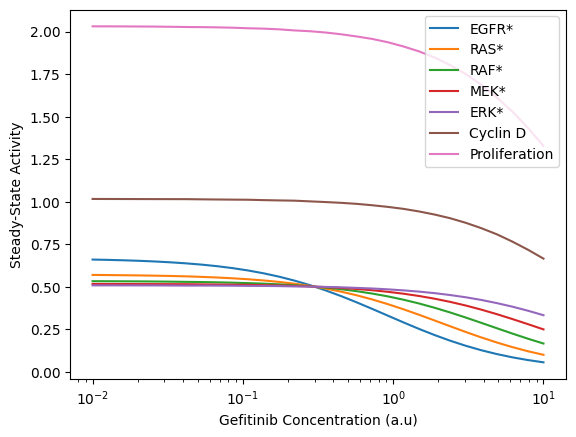

In [ ]:
y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

t_span = (0, 40)

t_eval = np.linspace(0, 40, 500)

params = {
    "EGF" : 1.0,
    "G" : 0.0,
    "IC_50" : 0.3,
    "n" : 1.0,
    "k_EGF" : 1.0,
    "k_EGFR_off" : 0.5,
    "k_G" : 0.5,
    "k_RAS" : 1.0,
    "k_RAS_off" : 0.5,
    "k_RAF" : 1.0,
    "k_RAF_off" : 0.5,
    "k_MEK" : 1.0,
    "k_MEK_off" : 0.5,
    "k_ERK" : 1.0,
    "k_ERK_off" : 0.5,
    "k_T" : 1.0,
    "k_deg" : 0.5,
    "k_P" : 1.0,
    "k_loss" : 0.5,
}

G_values = np.logspace(-2, 1, 30)
# ERK_ss_values = []

# for G in G_values:
    # params["G"] = G
    # solution = solve_ivp(pathway, t_span, y0, t_eval= t_eval, args=(params,))

    # ERK_ss = solution.y[4, -1]
    
    # ERK_ss_values.append(ERK_ss)
# plt.plot(G_values, ERK_ss_values)

# print(f'G array : {G_values}')
# print(f'ERK array : {ERK_ss_values}')

# plt.xlabel('Gefitinib Concentration (a.u)')
# plt.ylabel('Relative ERK Steady State Activity')

# plt.show()

steady_states = []

for G in G_values:
    params["G"] = G
    solution = solve_ivp(pathway, t_span, y0, t_eval= t_eval, args=(params,))

    steady_states.append(solution.y[:, -1])

steady_states = np.array(steady_states)

plt.plot(G_values, steady_states[:, 0], label='EGFR*')
plt.plot(G_values, steady_states[:, 1], label='RAS*')
plt.plot(G_values, steady_states[:, 2], label='RAF*')
plt.plot(G_values, steady_states[:, 3], label='MEK*')
plt.plot(G_values, steady_states[:, 4], label='ERK*')
plt.plot(G_values, steady_states[:, 5], label='Cyclin D')
plt.plot(G_values, steady_states[:, 6], label='Proliferation')

plt.xlabel('Gefitinib Concentration (a.u)')
plt.ylabel('Steady-State Activity')

plt.xscale("log")

plt.legend()
plt.show()